# Data Collection Pipeline — CC-NEWS

**Project:** SPZ — Geographic Bias in Pre-Trained Sentiment Classifiers

**Author:** Rezvaneh Mousavi | JLU Giessen | M.Sc. Data Analytics

**Supervisor:** Prof. Dr. Stefan Hennemann

---

**Purpose of this notebook:**

This notebook collects English-language news articles from the Common Crawl News (CC-NEWS) archive, extracts lead paragraphs, and assigns an initial country-of-publication label based on the article's source domain. This constitutes the first of three independent geographic assignment methods used in this study (URL-based, NER-based, and manual annotation).

**Pipeline overview:**

1. Download WARC archive files from CC-NEWS to temporary storage
2. Extract article text from raw HTML using trafilatura
3. Filter for English-language articles using langdetect
4. Remove non-news domains via blacklist
5. Extract lead paragraphs (first 3-4 sentences) from each article
6. Assign country of publication based on a curated domain-to-country mapping
7. Save results to Google Drive

**Lead extraction rationale:** In news writing, the lead paragraph is designed to convey the article's core information and stance. Sentiment classifiers are applied to the lead rather than the full text, as this was validated in the previous project and recommended by Prof. Hennemann. Both the full text and the lead are retained in the dataset.

**Data persistence:** Each processing stage saves its output to Google Drive. If the Colab session expires, re-running a cell will load the existing output rather than reprocessing from scratch.

---
## 0. Setup and Configuration

In [1]:
# Install required packages:
# warcio       - reads WARC (Web ARChive) files record by record
# trafilatura  - extracts main article text from raw HTML, removing navigation, ads, footers
# langdetect   - statistical language identification
# tldextract   - decomposes URLs into subdomain, domain, and suffix components
#                e.g. "www.bbc.co.uk" -> subdomain="www", domain="bbc", suffix="co.uk"

!pip install -q warcio trafilatura langdetect tldextract

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.9 MB/s eta 0:00:00


In [2]:
import os
import re
import gzip
import logging
import requests
import pandas as pd
from io import BytesIO
from warcio.archiveiterator import ArchiveIterator
from trafilatura import extract
from langdetect import detect, LangDetectException
import tldextract
from datetime import datetime

# Suppress trafilatura's verbose warnings ("discarding data", "empty HTML tree").
# These are normal for WARC processing — many records are not valid articles.
logging.getLogger('trafilatura').setLevel(logging.CRITICAL)

print('All imports loaded successfully.')

All imports loaded successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- Path configuration ---
# This path assumes you have added a shortcut to the "UNI" folder in My Drive.
# To do this: Google Drive > Shared with me > right-click UNI > Organise > Add shortcut to Drive > My Drive
#
# If your folder structure differs, adjust DRIVE_BASE accordingly.

DRIVE_BASE = '/content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule'
DATA_RAW = f'{DRIVE_BASE}/data/raw'
DATA_PROCESSED = f'{DRIVE_BASE}/data/processed'

for folder in [DATA_RAW, DATA_PROCESSED]:
    os.makedirs(folder, exist_ok=True)

assert os.path.exists(DRIVE_BASE), f'Path not found: {DRIVE_BASE} -- check your Drive shortcut.'
print(f'Working directory: {DRIVE_BASE}')
print(f'Data (raw):       {DATA_RAW}')
print(f'Data (processed): {DATA_PROCESSED}')

Working directory: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule
Data (raw):       /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw
Data (processed): /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed


In [5]:
# --- Collection parameters ---

TARGET_YEAR = '2025'
TARGET_MONTH = '01'          # January 2025
MAX_WARC_FILES = 3           # Number of WARC files to process (start small, increase as needed)
MIN_ARTICLE_LENGTH = 200     # Minimum character count to consider a valid article

---
## 1. Retrieve WARC File Listing

CC-NEWS organises its archive by month. Each month has a listing file (`warc.paths.gz`) that contains the paths to all WARC files collected during that period. Each WARC file is a compressed archive holding thousands of individual web page captures from news sites worldwide.

Reference: https://data.commoncrawl.org/crawl-data/CC-NEWS/index.html

In [6]:
listing_url = f'https://data.commoncrawl.org/crawl-data/CC-NEWS/{TARGET_YEAR}/{TARGET_MONTH}/warc.paths.gz'
print(f'Requesting WARC listing: {listing_url}')

response = requests.get(listing_url)
response.raise_for_status()

warc_paths = gzip.decompress(response.content).decode('utf-8').strip().split('\n')
print(f'Available WARC files for {TARGET_YEAR}/{TARGET_MONTH}: {len(warc_paths)}')
print(f'Will process: {min(MAX_WARC_FILES, len(warc_paths))}')

Requesting WARC listing: https://data.commoncrawl.org/crawl-data/CC-NEWS/2025/01/warc.paths.gz
Available WARC files for 2025/01: 403
Will process: 3


---
## 2. Pipeline Functions

The following cells define the core processing functions. They are executed in Section 3.

### 2.1 WARC Download and Article Extraction

A WARC file contains sequential records, each representing one HTTP transaction captured by the crawler. We filter for `response` records with HTML content, then use `trafilatura` to extract the main article body. Trafilatura is designed specifically for news and web content extraction: it identifies the primary content area and strips navigation elements, advertisements, and boilerplate.

In [7]:
def download_warc(warc_path):
    """Download a WARC file from Common Crawl into memory."""
    url = f'https://data.commoncrawl.org/{warc_path}'
    filename = warc_path.split('/')[-1]
    print(f'  Downloading {filename}...')
    response = requests.get(url, stream=True)
    response.raise_for_status()
    size_mb = len(response.content) / (1024 * 1024)
    print(f'  Size: {size_mb:.1f} MB')
    return BytesIO(response.content)

In [8]:
def extract_articles_from_warc(warc_stream, min_length=MIN_ARTICLE_LENGTH):
    """
    Extract article text, URL, and capture date from a WARC file.

    Processing logic:
    - Only HTTP response records are considered (not requests or metadata).
    - Only text/html content types are processed (images, PDFs, etc. are skipped).
    - trafilatura handles the HTML-to-text conversion.
    - Articles shorter than min_length characters are discarded, as these are
      typically navigation pages, error pages, or incomplete extractions.
    """
    articles = []
    skipped_non_html = 0
    skipped_short = 0
    errors = 0

    for record in ArchiveIterator(warc_stream):
        if record.rec_type != 'response':
            continue

        content_type = record.http_headers.get_header('Content-Type') or ''
        if 'text/html' not in content_type:
            skipped_non_html += 1
            continue

        try:
            url = record.rec_headers.get_header('WARC-Target-URI')
            date = record.rec_headers.get_header('WARC-Date')
            html = record.content_stream().read().decode('utf-8', errors='replace')
            text = extract(html)

            if text and len(text) >= min_length:
                articles.append({'url': url, 'date': date, 'text': text})
            else:
                skipped_short += 1
        except Exception:
            errors += 1
            continue

    print(f'  Extracted: {len(articles)} articles '
          f'| {skipped_non_html} non-HTML | {skipped_short} too short | {errors} errors')
    return articles

### 2.2 Language Detection and Domain Filtering

Two-stage filtering is applied:

1. **Language detection** via `langdetect`, applied to the first 500 characters of each article. This is sufficient for reliable identification and avoids unnecessary computation on full texts.

2. **Domain blacklist** to remove non-news domains (social media, aggregators, e-commerce) that pass the language filter. This approach was validated in the previous project, where language detection alone proved insufficient for clean filtering.

In [9]:
def detect_language(text):
    """Return ISO 639-1 language code, or None if detection fails."""
    try:
        return detect(text[:500])
    except LangDetectException:
        return None

In [10]:
DOMAIN_BLACKLIST = {
    # Social media and user-generated content
    'reddit.com', 'twitter.com', 'x.com', 'facebook.com',
    'youtube.com', 'instagram.com', 'tiktok.com',
    # News aggregators and portals
    'news.google.com', 'news.yahoo.com', 'msn.com',
    'flipboard.com', 'apple.news',
    # Weather and utilities
    'weather.com', 'accuweather.com',
    # Non-news
    'wikipedia.org', 'amazon.com', 'ebay.com',
    'pinterest.com', 'linkedin.com',
}


def is_blacklisted(url):
    """Check whether a URL belongs to a blacklisted domain."""
    try:
        ext = tldextract.extract(url)
        return ext.registered_domain in DOMAIN_BLACKLIST
    except Exception:
        return True  # reject unparseable URLs

### 2.3 Lead Paragraph Extraction

In news writing, the lead (or lede) is the opening paragraph that summarises the who, what, where, when, and why. Journalists design these first 3-4 sentences to convey the article's critical information and editorial stance.

Sentiment classifiers will be applied to the lead rather than the full article, for two reasons:
1. Leads are concise and carry a clear sentiment signal, whereas full articles contain mixed sentiment that dilutes the measurement.
2. This approach was validated in the previous semester project and recommended by Prof. Hennemann.

Both the full text and the extracted lead are retained in the dataset.

*(Adapted from Liubov Brandao da Silva's pipeline, previous semester project.)*

In [11]:
def split_paragraphs(text):
    """
    Split article text into paragraphs.

    Tries three strategies in order:
    1. Split on double newlines (standard paragraph separator)
    2. Split on single newlines (some sources use single breaks)
    3. Group sentences into blocks of 3 (fallback for unstructured text)
    """
    text = re.sub(r'\n{3,}', '\n\n', text)
    paras = [p.strip() for p in text.split('\n\n') if p.strip()]

    if len(paras) <= 1:
        paras = [p.strip() for p in text.split('\n') if p.strip()]

    if len(paras) <= 1:
        sentences = re.split(r'(?<=[.!?])\s+', text)
        paras = [' '.join(sentences[i:i+3]) for i in range(0, len(sentences), 3)]

    return paras


def extract_lead(text):
    """
    Extract the lead paragraph from a news article.

    If the first paragraph is very short (< 180 characters), it is combined
    with the second paragraph. This handles cases where the dateline, byline,
    or a brief subheading is treated as a separate paragraph by the extractor.

    Returns:
        (lead_text, lead_status)
        lead_status is one of:
        - 'ok': valid lead extracted
        - 'flagged': lead is short but usable (< 120 chars)
        - 'rejected': no usable lead could be extracted
    """
    paragraphs = split_paragraphs(text)

    if not paragraphs:
        return None, 'rejected'

    lead = paragraphs[0]

    # Combine with second paragraph if first is very short
    if len(lead) < 180 and len(paragraphs) > 1:
        lead = lead + ' ' + paragraphs[1]

    if len(lead) < 120:
        return lead, 'flagged'

    # Cap length to avoid overly long leads
    if len(lead) > 1200:
        lead = lead[:1200]

    return lead, 'ok'

### 2.4 URL-Based Country Assignment (Method 1 of 3)

This is the first and simplest of the three geographic assignment methods used in this study. It maps each article's source domain to a country of publication using a curated lookup table.

**What it captures:** Where the article was *published* (i.e., the news organisation's country of origin).

**What it does not capture:** What country the article is *about*. For example, a BBC article reporting on Indian elections would be labelled UK by this method. The NER + Geonames approach (Method 2, Notebook 02) addresses this distinction.

**Limitations:**
- Only works for domains explicitly listed in the mapping.
- Articles from unlisted domains are marked as unassigned, not discarded.
- The mapping is expanded iteratively based on the frequency distribution of unassigned domains.

Country selection is data-driven: the initial mapping covers five target regions (US, UK, Australia, India, Germany), but the final set of included countries depends on which sources yield sufficient article counts in the data.

In [12]:
DOMAIN_TO_COUNTRY = {
    # --- United States ---
    'nytimes.com': 'US',
    'washingtonpost.com': 'US',
    'apnews.com': 'US',
    'foxnews.com': 'US',
    'cnn.com': 'US',
    'usatoday.com': 'US',
    'latimes.com': 'US',
    'nbcnews.com': 'US',
    'cbsnews.com': 'US',
    'npr.org': 'US',
    'politico.com': 'US',
    'thehill.com': 'US',
    'reuters.com': 'US',
    'bloomberg.com': 'US',

    # --- United Kingdom ---
    'bbc.co.uk': 'UK',
    'bbc.com': 'UK',
    'theguardian.com': 'UK',
    'telegraph.co.uk': 'UK',
    'independent.co.uk': 'UK',
    'dailymail.co.uk': 'UK',
    'mirror.co.uk': 'UK',
    'thetimes.co.uk': 'UK',
    'sky.com': 'UK',

    # --- Australia ---
    'abc.net.au': 'AU',
    'smh.com.au': 'AU',
    'news.com.au': 'AU',
    'theaustralian.com.au': 'AU',
    'sbs.com.au': 'AU',
    '9news.com.au': 'AU',

    # --- India ---
    'thehindu.com': 'IN',
    'ndtv.com': 'IN',
    'hindustantimes.com': 'IN',
    'indianexpress.com': 'IN',
    'firstpost.com': 'IN',
    'theprint.in': 'IN',
    'scroll.in': 'IN',
    'livemint.com': 'IN',
    'deccanherald.com': 'IN',

    # --- Germany (English-language output) ---
    'dw.com': 'DE',
}

# Some news sources use a subdomain as part of their identity.
# These require a separate lookup that includes the subdomain.
SUBDOMAIN_TO_COUNTRY = {
    'timesofindia.indiatimes.com': 'IN',
    'abcnews.go.com': 'US',
}


def assign_country_by_url(url):
    """
    Map an article's URL to a country of publication.

    Uses a two-pass lookup:
    1. Check the full domain including subdomain (handles cases like
       timesofindia.indiatimes.com where the subdomain is essential).
    2. Check the registered domain only (standard cases like bbc.co.uk).

    Returns a country code (e.g., 'US', 'UK') or None if not in the mapping.
    """
    try:
        ext = tldextract.extract(url)
        registered_domain = ext.registered_domain

        # Pass 1: subdomain-specific lookup
        if ext.subdomain:
            full_domain = f'{ext.subdomain}.{registered_domain}'
            if full_domain in SUBDOMAIN_TO_COUNTRY:
                return SUBDOMAIN_TO_COUNTRY[full_domain]

        # Pass 2: registered domain lookup
        if registered_domain in DOMAIN_TO_COUNTRY:
            return DOMAIN_TO_COUNTRY[registered_domain]

        return None
    except Exception:
        return None


n_domains = len(DOMAIN_TO_COUNTRY) + len(SUBDOMAIN_TO_COUNTRY)
n_countries = len(set(list(DOMAIN_TO_COUNTRY.values()) + list(SUBDOMAIN_TO_COUNTRY.values())))
print(f'Domain mapping loaded: {n_domains} domains across {n_countries} countries')

Domain mapping loaded: 41 domains across 5 countries


---
## 3. Execute Pipeline

### 3.1 WARC Extraction

Each WARC file is downloaded into temporary memory, processed, and discarded. Only the extracted article data is retained. WARC files can be re-downloaded from Common Crawl at any time and do not need to be stored.

In [13]:
raw_output_path = f'{DATA_RAW}/articles_raw_{TARGET_YEAR}_{TARGET_MONTH}.csv'

if os.path.exists(raw_output_path):
    print(f'Checkpoint found: {raw_output_path}')
    df_raw = pd.read_csv(raw_output_path)
    print(f'Loaded {len(df_raw)} articles from previous run.')

else:
    print(f'Processing {MAX_WARC_FILES} WARC files from {TARGET_YEAR}/{TARGET_MONTH}\n')

    all_articles = []
    files_to_process = warc_paths[:MAX_WARC_FILES]

    for i, warc_path in enumerate(files_to_process, 1):
        print(f'[{i}/{len(files_to_process)}]')
        warc_stream = download_warc(warc_path)
        articles = extract_articles_from_warc(warc_stream)
        all_articles.extend(articles)
        del warc_stream  # free memory
        print(f'  Cumulative total: {len(all_articles)} articles\n')

    df_raw = pd.DataFrame(all_articles)
    df_raw.to_csv(raw_output_path, index=False)
    print(f'Saved {len(df_raw)} raw articles to {raw_output_path}')

Checkpoint found: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw/articles_raw_2025_01.csv
Loaded 73588 articles from previous run.


### 3.2 Language Filtering, Domain Blacklist, and Lead Extraction

In [14]:
eng_output_path = f'{DATA_RAW}/articles_english_{TARGET_YEAR}_{TARGET_MONTH}.csv'

if os.path.exists(eng_output_path):
    print(f'Checkpoint found: {eng_output_path}')
    df_eng = pd.read_csv(eng_output_path)
    print(f'Loaded {len(df_eng)} English articles from previous run.')

else:
    print(f'Filtering {len(df_raw)} articles...\n')

    # Stage 1: language detection
    df_raw['lang'] = df_raw['text'].apply(detect_language)
    print('Language distribution (top 10):')
    print(df_raw['lang'].value_counts().head(10).to_string())

    df_eng = df_raw[df_raw['lang'] == 'en'].copy()
    print(f'\nAfter language filter: {len(df_eng)} articles')

    # Stage 2: domain blacklist
    before = len(df_eng)
    df_eng = df_eng[~df_eng['url'].apply(is_blacklisted)].copy()
    print(f'After domain blacklist: {len(df_eng)} articles (removed {before - len(df_eng)})')

    # Stage 3: extract domain metadata
    df_eng['registered_domain'] = df_eng['url'].apply(
        lambda u: tldextract.extract(u).registered_domain
    )
    df_eng['domain_suffix'] = df_eng['url'].apply(
        lambda u: tldextract.extract(u).suffix
    )

    # Stage 4: lead extraction
    print('\nExtracting lead paragraphs...')
    df_eng[['lead_text', 'lead_status']] = df_eng['text'].apply(
        lambda t: pd.Series(extract_lead(t))
    )
    print('Lead status distribution:')
    print(df_eng['lead_status'].value_counts().to_string())

    df_eng = df_eng.drop(columns=['lang'])

    df_eng.to_csv(eng_output_path, index=False)
    print(f'\nSaved {len(df_eng)} English articles to {eng_output_path}')

Filtering 73588 articles...

Language distribution (top 10):
lang
en    15321
ru    10056
fr     7242
bn     4302
tr     4120
ko     3185
es     3107
it     3046
pt     2626
ar     2295

After language filter: 15321 articles


/tmp/ipykernel_9631/1849095297.py:20: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return ext.registered_domain in DOMAIN_BLACKLIST
/tmp/ipykernel_9631/1631330531.py:26: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  lambda u: tldextract.extract(u).registered_domain


After domain blacklist: 15321 articles (removed 0)

Extracting lead paragraphs...
Lead status distribution:
lead_status
ok         12600
flagged     2721

Saved 15321 English articles to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw/articles_english_2025_01.csv


### 3.3 Country Assignment (URL-Based)

In [15]:
country_output_path = f'{DATA_PROCESSED}/articles_with_country_{TARGET_YEAR}_{TARGET_MONTH}.csv'

if os.path.exists(country_output_path):
    print(f'Checkpoint found: {country_output_path}')
    df = pd.read_csv(country_output_path)
    print(f'Loaded {len(df)} articles from previous run.')

else:
    print(f'Assigning countries to {len(df_eng)} articles...\n')

    df_eng['country_url'] = df_eng['url'].apply(assign_country_by_url)

    assigned = df_eng['country_url'].notna().sum()
    unassigned = df_eng['country_url'].isna().sum()
    print(f'Assigned: {assigned} | Unassigned: {unassigned}\n')

    print('Country distribution (assigned articles):')
    print(df_eng['country_url'].value_counts().to_string())

    print(f'\nTop 20 unassigned domains (candidates for expanding the mapping):')
    unassigned_df = df_eng[df_eng['country_url'].isna()]
    print(unassigned_df['registered_domain'].value_counts().head(20).to_string())

    df = df_eng.copy()
    df.to_csv(country_output_path, index=False)
    print(f'\nSaved {len(df)} articles to {country_output_path}')

Assigning countries to 15321 articles...

Assigned: 1257 | Unassigned: 14064

Country distribution (assigned articles):
country_url
IN    912
US    174
UK    140
DE     31

Top 20 unassigned domains (candidates for expanding the mapping):
registered_domain
etfdailynews.com         500
business-standard.com    428
menafn.com               260
thehawk.in               254
latestly.com             252
lokmattimes.com          222
timesnownews.com         181
goal.com                 178
indiatimes.com           161
newindianexpress.com     158
cbssports.com            158
republicworld.com        151
yahoo.com                150
365project.org           149
newsdrum.in              145
khaleejtimes.com         140
thehansindia.com         139
rotowire.com             130
telegraphindia.com       116
sakshipost.com           114


/tmp/ipykernel_9631/3400586753.py:73: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  registered_domain = ext.registered_domain



Saved 15321 articles to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_country_2025_01.csv


---
## 4. Collection Summary

In [16]:
separator = '-' * 50

print(f'COLLECTION SUMMARY: CC-NEWS {TARGET_YEAR}/{TARGET_MONTH}')
print(f'WARC files processed: {MAX_WARC_FILES}')
print(separator)
print(f'Total extracted articles (all languages): {len(df_raw)}')
print(f'English articles (after filtering):       {len(df_eng)}')
print(f'Articles with country assigned:           {df["country_url"].notna().sum()}')
print(f'Articles without country assignment:      {df["country_url"].isna().sum()}')
print(separator)

print(f'\nArticles per country:')
print(df['country_url'].value_counts().to_string())

print(f'\nLead extraction status:')
print(df['lead_status'].value_counts().to_string())

print(f'\nTop 15 domains in dataset:')
print(df['registered_domain'].value_counts().head(15).to_string())

df['text_length'] = df['text'].str.len()
df['lead_length'] = df['lead_text'].str.len()
print(f'\nMean article length (characters) by country:')
country_lengths = df.groupby('country_url')['text_length'].mean().round(0).astype(int)
print(country_lengths.to_string())

print(f'\nMean lead length (characters) by country:')
lead_lengths = df.groupby('country_url')['lead_length'].mean().round(0).astype(int)
print(lead_lengths.to_string())

COLLECTION SUMMARY: CC-NEWS 2025/01
WARC files processed: 3
--------------------------------------------------
Total extracted articles (all languages): 73588
English articles (after filtering):       15321
Articles with country assigned:           1257
Articles without country assignment:      14064
--------------------------------------------------

Articles per country:
country_url
IN    912
US    174
UK    140
DE     31

Lead extraction status:
lead_status
ok         12600
flagged     2721

Top 15 domains in dataset:
registered_domain
etfdailynews.com         500
livemint.com             454
business-standard.com    428
menafn.com               260
thehawk.in               254
latestly.com             252
hindustantimes.com       250
lokmattimes.com          222
indiatimes.com           216
timesnownews.com         181
goal.com                 178
cbssports.com            158
newindianexpress.com     158
republicworld.com        151
yahoo.com                150

Mean article length

In [17]:
# Verify saved files on Drive
print('Files saved to Drive:\n')
for label, path in [('raw', DATA_RAW), ('processed', DATA_PROCESSED)]:
    if os.path.exists(path):
        for f in sorted(os.listdir(path)):
            fpath = os.path.join(path, f)
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            print(f'  {label}/{f}  ({size_mb:.1f} MB)')

Files saved to Drive:

  raw/articles_english_2025_01.csv  (53.7 MB)
  raw/articles_raw_2025_01.csv  (256.0 MB)
  processed/articles_with_country_2025_01.csv  (53.7 MB)
  processed/collection_overview_2025_01.png  (0.2 MB)


---
## 5. Visualisation

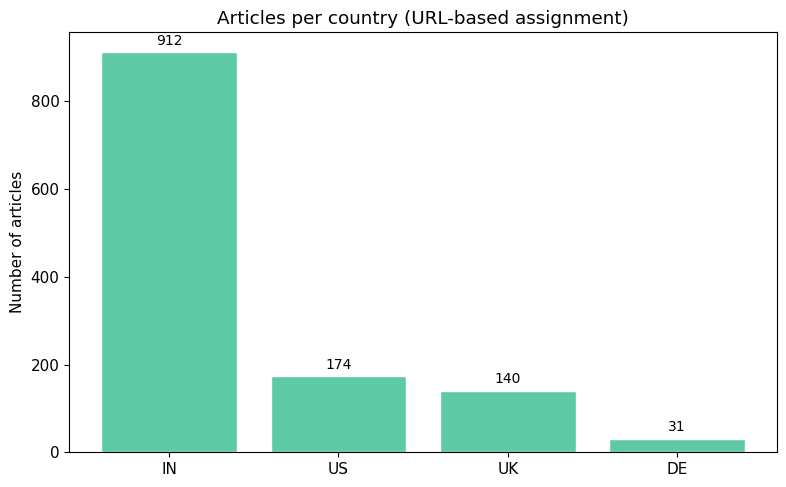

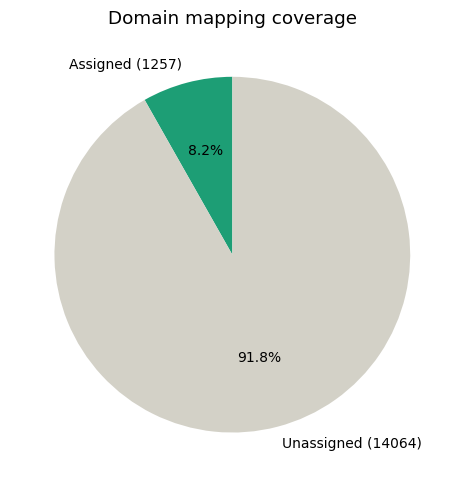

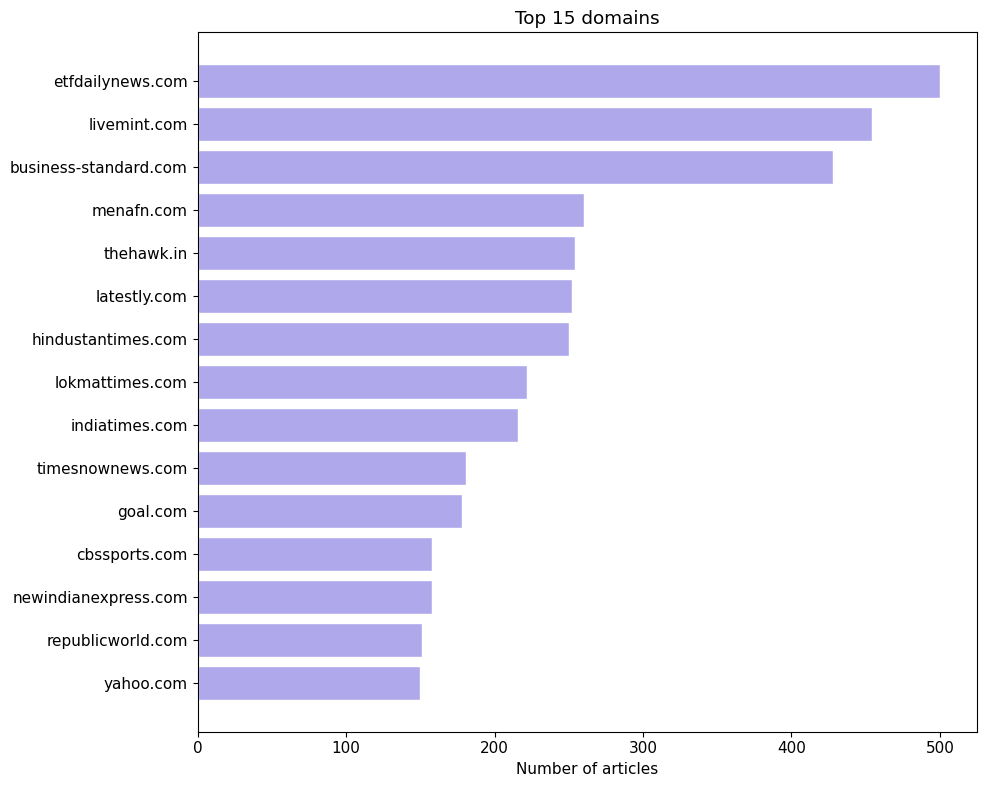

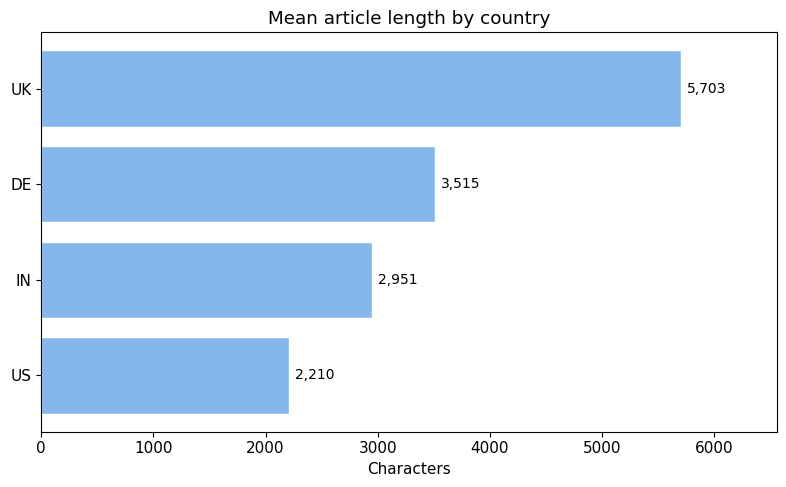

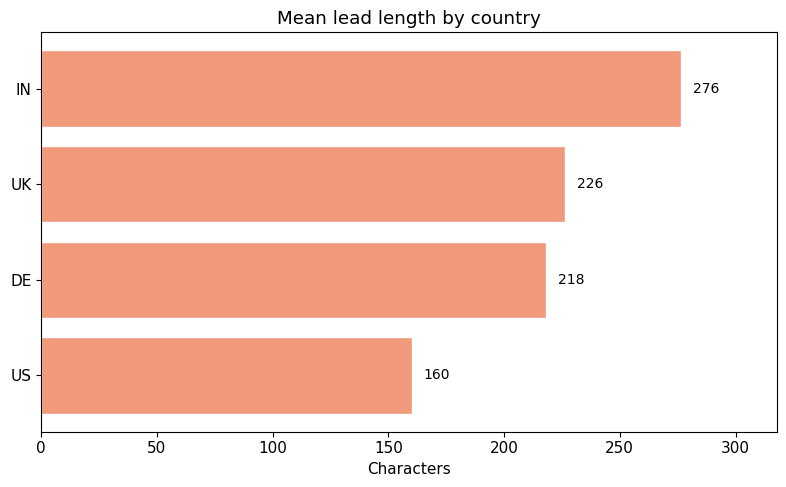

All figures saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/


In [27]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})

# --- 1. Articles per country ---
fig, ax = plt.subplots(figsize=(8, 5))
country_counts = df['country_url'].value_counts()
bars = ax.bar(country_counts.index, country_counts.values,
              color='#5DCAA5', edgecolor='white')
ax.set_title('Articles per country (URL-based assignment)')
ax.set_ylabel('Number of articles')
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig_country_counts_{TARGET_YEAR}_{TARGET_MONTH}.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- 2. Assigned vs unassigned ---
fig, ax = plt.subplots(figsize=(6, 5))
assigned = df['country_url'].notna().sum()
unassigned = df['country_url'].isna().sum()
ax.pie([assigned, unassigned],
       labels=[f'Assigned ({assigned})', f'Unassigned ({unassigned})'],
       colors=['#1D9E75', '#D3D1C7'], startangle=90,
       autopct='%1.1f%%', textprops={'fontsize': 10})
ax.set_title('Domain mapping coverage')
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig_coverage_{TARGET_YEAR}_{TARGET_MONTH}.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Top 15 domains ---
fig, ax = plt.subplots(figsize=(10, 8))
top_domains = df['registered_domain'].value_counts().head(15)
ax.barh(top_domains.index[::-1], top_domains.values[::-1],
        color='#AFA9EC', edgecolor='white')
ax.set_title('Top 15 domains')
ax.set_xlabel('Number of articles')
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig_top_domains_{TARGET_YEAR}_{TARGET_MONTH}.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Mean article length by country ---
fig, ax = plt.subplots(figsize=(8, 5))
df['text_length'] = df['text'].str.len()
length_by_country = df.groupby('country_url')['text_length'].mean().sort_values(ascending=True)
bars = ax.barh(length_by_country.index, length_by_country.values,
               color='#85B7EB', edgecolor='white')
ax.set_title('Mean article length by country')
ax.set_xlabel('Characters')
ax.set_xlim(0, length_by_country.max() * 1.15)  # 15% padding for labels
for bar, val in zip(bars, length_by_country.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig_article_length_{TARGET_YEAR}_{TARGET_MONTH}.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- 5. Mean lead length by country ---
fig, ax = plt.subplots(figsize=(8, 5))
df['lead_length'] = df['lead_text'].str.len()
lead_by_country = df.groupby('country_url')['lead_length'].mean().sort_values(ascending=True)
bars = ax.barh(lead_by_country.index, lead_by_country.values,
               color='#F0997B', edgecolor='white')
ax.set_title('Mean lead length by country')
ax.set_xlabel('Characters')
ax.set_xlim(0, lead_by_country.max() * 1.15)
for bar, val in zip(bars, lead_by_country.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig_lead_length_{TARGET_YEAR}_{TARGET_MONTH}.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'All figures saved to {DATA_PROCESSED}/')

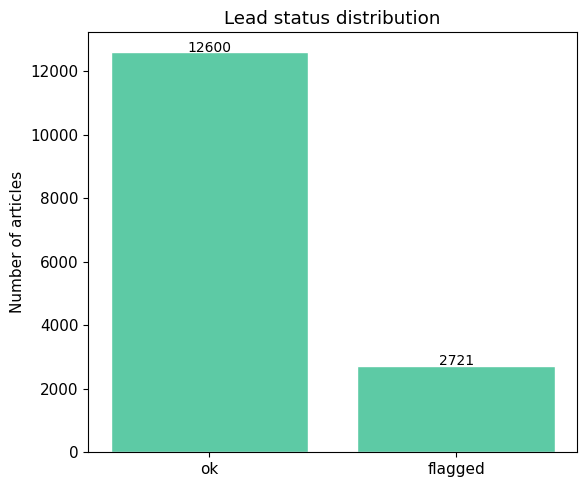

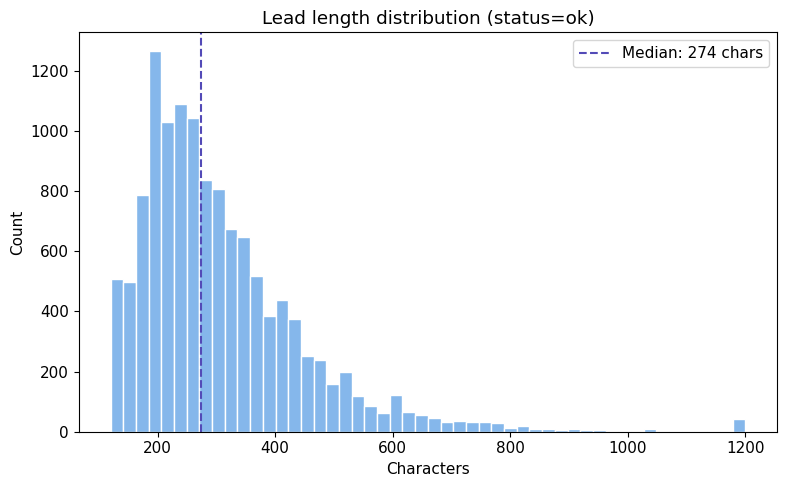

In [28]:
# --- 6. Lead status distribution ---
fig, ax = plt.subplots(figsize=(6, 5))
status_counts = df['lead_status'].value_counts()
bars = ax.bar(status_counts.index, status_counts.values, color='#5DCAA5', edgecolor='white')
ax.set_title('Lead status distribution')
ax.set_ylabel('Number of articles')
for i, (idx, val) in enumerate(status_counts.items()):
    ax.text(i, val + 20, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig06_lead_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 7. Lead length histogram ---
fig, ax = plt.subplots(figsize=(8, 5))
ok_leads = df[df['lead_status'] == 'ok']['lead_text'].str.len()
ax.hist(ok_leads, bins=50, color='#85B7EB', edgecolor='white')
ax.set_title('Lead length distribution (status=ok)')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.axvline(ok_leads.median(), color='#534AB7', linestyle='--',
           label=f'Median: {ok_leads.median():.0f} chars')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/fig07_lead_length_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Sample Articles

Manual inspection of a few extracted articles to verify quality.

In [30]:
# Show 2 sample articles per assigned country
for country in df['country_url'].dropna().unique():
    subset = df[df['country_url'] == country]
    samples = subset.sample(min(2, len(subset)), random_state=42)

    print(f'\n{"=" * 60}')
    print(f'COUNTRY: {country} ({len(subset)} articles)')
    print(f'{"=" * 60}')

    for _, row in samples.iterrows():
        print(f'\nURL:    {row["url"][:100]}')
        print(f'Domain: {row["registered_domain"]}')
        print(f'Lead status: {row["lead_status"]}')
        print(f'Lead ({len(str(row["lead_text"]))} chars):')
        print(f'  {str(row["lead_text"])[:300]}...')
        print()


COUNTRY: US (174 articles)

URL:    https://www.cbsnews.com/sacramento/video/what-do-these-new-years-traditions-mean-the-answer/
Domain: cbsnews.com
Lead status: flagged
Lead (11 chars):
  Latest U.S....


URL:    https://www.cbsnews.com/losangeles/video/thousands-flock-to-gloria-molina-grand-park-for-los-angeles
Domain: cbsnews.com
Lead status: ok
Lead (265 chars):
  Thousands flock to Gloria Molina Grand Park for Los Angeles' New Year's Eve celebrations Tom Wait reports from Gloria Molina Grand Park outside of Los Angeles City Hall, where thousands of people were gathered for the highly anticipated New Year's Eve celebrations....


COUNTRY: IN (912 articles)

URL:    https://www.livemint.com/market/stock-market-news/qips-qualified-institutional-placements-fundraisin
Domain: livemint.com
Lead status: flagged
Lead (82 chars):
  Indian QIPs hit a record high in 2024. Will the frenzy continue this year? Summary...


URL:    https://www.ndtv.com/entertainment/bhagyashree-on-thinking-his-

---
## 7. Next Steps

**Based on the output above:**

- Review the list of unassigned domains. High-frequency domains from English-speaking countries should be added to `DOMAIN_TO_COUNTRY` and the pipeline re-run.
- Assess country balance. If any target country has fewer than approximately 200 articles, increase `MAX_WARC_FILES` and re-run from Section 3.1. (Delete the corresponding checkpoint file first.)
- To add a second month of data, change `TARGET_YEAR` and `TARGET_MONTH` and re-run from Section 1. File names include the month, so existing checkpoints are not affected.

**Subsequent notebooks:**

- **Notebook 02 — NER + Geonames:** Extract geographic entities from article text using spaCy NER, then map them to standardised country codes using the Geonames.org database (Method 2 of 3).
- **Notebook 03 — Syntactic covariates:** Compute per-article metrics (average word length, sentence length, paragraph length) for use as regression controls.
- **Notebook 04 — Sentiment scoring:** Apply VADER and RoBERTa classifiers to the lead paragraphs.